In [2]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn import metrics


In [3]:
car_data=pd.read_csv("car data.csv")
#print 5first element
car_data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
#print last 5 elements
car_data.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [5]:
#print infos
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [6]:
#print columns
print(car_data.columns)

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')


In [7]:
car_data.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [8]:
print(car_data["Fuel_Type"].value_counts())

Petrol    239
Diesel     60
CNG         2
Name: Fuel_Type, dtype: int64


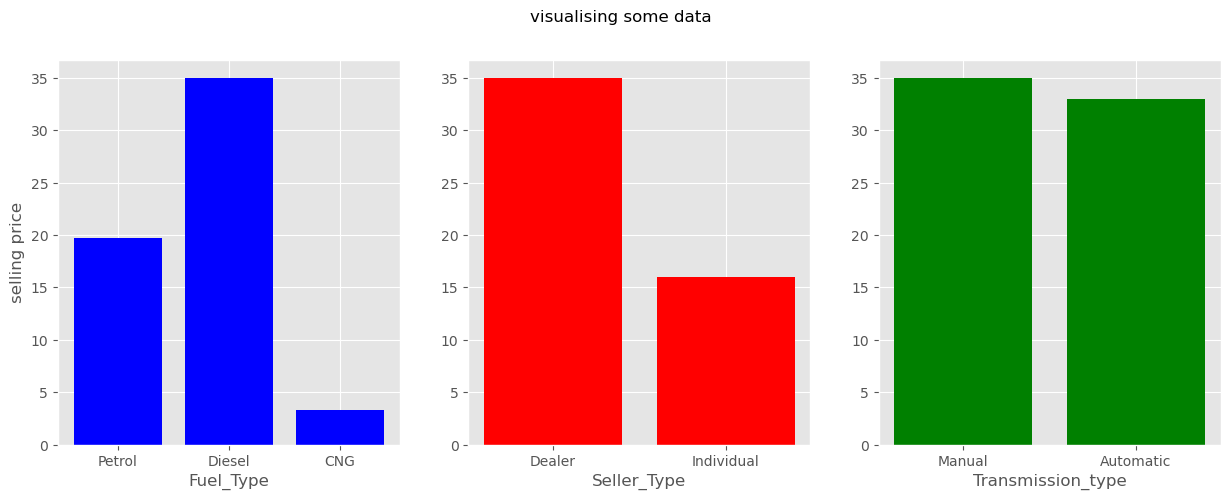

In [9]:
#graph
Fuel_Type=car_data["Fuel_Type"]
Seller_Type=car_data['Seller_Type']
Transmission_type=car_data["Transmission"]
Selling_Price=car_data["Selling_Price"]

from matplotlib import style
style.use("ggplot")
fig=plt.figure(figsize=(15,5))
fig.suptitle("visualising some data")
plt.subplot(1,3,1)
plt.bar(Fuel_Type,Selling_Price,color="blue")
plt.xlabel("Fuel_Type")
plt.ylabel("selling price")
plt.subplot(1,3,2)
plt.bar(Seller_Type,Selling_Price,color="red")
plt.xlabel("Seller_Type")
plt.subplot(1,3,3)
plt.bar(Transmission_type, Selling_Price,color="green") 
plt.xlabel('Transmission_type')
plt.show()




In [10]:
print (car_data)

    Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0       ritz  2014           3.35           5.59       27000    Petrol   
1        sx4  2013           4.75           9.54       43000    Diesel   
2       ciaz  2017           7.25           9.85        6900    Petrol   
3    wagon r  2011           2.85           4.15        5200    Petrol   
4      swift  2014           4.60           6.87       42450    Diesel   
..       ...   ...            ...            ...         ...       ...   
296     city  2016           9.50          11.60       33988    Diesel   
297     brio  2015           4.00           5.90       60000    Petrol   
298     city  2009           3.35          11.00       87934    Petrol   
299     city  2017          11.50          12.50        9000    Diesel   
300     brio  2016           5.30           5.90        5464    Petrol   

    Seller_Type Transmission  Owner  
0        Dealer       Manual      0  
1        Dealer       Manual      0

In [11]:
#configuring targets and features
x=car_data.drop(columns=["Selling_Price","Car_Name","Fuel_Type","Transmission","Seller_Type"],axis=1)
y=car_data['Selling_Price']
print (y)


0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 301, dtype: float64


In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.3,random_state=42)
print("shape of x test",x_train.shape)
print("shape of x train",x_test.shape)
print("shape of y train",y_train.shape)
print("shape of y test",y_test.shape)



shape of x test (210, 4)
shape of x train (91, 4)
shape of y train (210,)
shape of y test (91,)


In [13]:
Model=LinearRegression()
Model.fit(x_train,y_train)
prediction=Model.predict(x_test)


In [14]:
x=[[2013,9.54,43000,0]]
Model.predict(x)

c:\Users\USER\anaconda3\envs\ML\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([5.3990051])

In [15]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,accuracy_score
print("MAE",metrics.mean_absolute_error(prediction,y_test))
print("MSE",metrics.mean_squared_error(prediction,y_test))
print("accuracy score",metrics.r2_score(prediction,y_test))
#accuracy score for logisticregression?


MAE 1.4325451507194453
MSE 4.173183190823652
accuracy score 0.7598244925749785


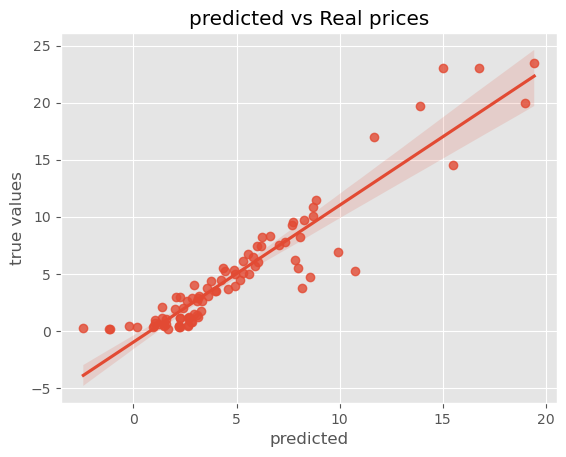

In [16]:
sb.regplot(x=prediction,y=y_test)
plt.xlabel("predicted")
plt.ylabel("true values")
plt.title("predicted vs Real prices")
plt.show()